In [1]:
!pip install -q xgboost shap fairlearn statsmodels scipy seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 3.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from pathlib import Path

PROJECT_DIR = Path("/content/AIF-8A-Bias-Audit")

DATA_DIR = PROJECT_DIR / "data"
SRC_DIR = PROJECT_DIR / "src"
REPORT_DIR = PROJECT_DIR / "reports"
VIS_DIR = PROJECT_DIR / "visualisations"
DOCS_DIR = PROJECT_DIR / "docs"

for directory in [
    DATA_DIR,
    SRC_DIR,
    REPORT_DIR,
    VIS_DIR,
    DOCS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [4]:
n_samples = 50_000

rng = np.random.default_rng(RANDOM_STATE)

gender = rng.choice(
    ["Male", "Female"],
    size=n_samples,
    p=[0.55, 0.45]
)

city_tier = rng.choice(
    ["Tier 1", "Tier 2", "Tier 3"],
    size=n_samples,
    p=[0.40, 0.35, 0.25]
)

age = rng.integers(21, 65, size=n_samples)

annual_income = rng.normal(
    loc=50_000,
    scale=15_000,
    size=n_samples
).clip(15_000, 200_000)

credit_score = rng.integers(
    300,
    851,
    size=n_samples
)

employment_type = rng.choice(
    ["Salaried", "Self-employed", "Unemployed"],
    size=n_samples,
    p=[0.65, 0.25, 0.10]
)

existing_debt = rng.normal(
    loc=20_000,
    scale=10_000,
    size=n_samples
).clip(0, 100_000)

loan_amount = rng.normal(
    loc=150_000,
    scale=60_000,
    size=n_samples
).clip(20_000, 500_000)

monthly_expenses = rng.normal(
    loc=20_000,
    scale=7_000,
    size=n_samples
).clip(5_000, 80_000)

debt_to_income = existing_debt / annual_income

# Simulated ground-truth eligibility.
# Protected attributes are not directly used here.
true_eligibility_score = (
    0.50 * (credit_score / 850)
    + 0.25 * (annual_income / 200_000)
    - 0.15 * debt_to_income
    - 0.10 * (loan_amount / 500_000)
)

true_eligibility = (
    true_eligibility_score
    > np.quantile(true_eligibility_score, 0.55)
).astype(int)

# Simulated model score with intentionally introduced disparities.
model_score = (
    true_eligibility_score
    + 0.12 * (gender == "Male")
    + 0.10 * (city_tier == "Tier 1")
)

loan_approved = (
    model_score
    > np.quantile(model_score, 0.55)
).astype(int)

df = pd.DataFrame({
    "gender": gender,
    "city_tier": city_tier,
    "age": age,
    "annual_income": np.round(annual_income, 2),
    "credit_score": credit_score,
    "employment_type": employment_type,
    "existing_debt": np.round(existing_debt, 2),
    "loan_amount": np.round(loan_amount, 2),
    "monthly_expenses": np.round(monthly_expenses, 2),
    "debt_to_income": np.round(debt_to_income, 4),
    "true_eligibility": true_eligibility,
    "loan_approved": loan_approved
})

dataset_path = DATA_DIR / "dataset_50k.csv"
df.to_csv(dataset_path, index=False)

print("Dataset created successfully.")
print("Dataset shape:", df.shape)

display(df.head())


Dataset created successfully.
Dataset shape: (50000, 12)


,gender,city_tier,age,annual_income,credit_score,employment_type,existing_debt,loan_amount,monthly_expenses,debt_to_income,true_eligibility,loan_approved
0,Female,Tier 3,64,41821.41,850,Salaried,24604.78,154157.64,14924.03,0.5883,1,1
1,Male,Tier 2,62,71060.82,523,Self-employed,5367.10,127216.46,23875.51,0.0755,1,1
2,Female,Tier 2,63,34264.08,375,Salaried,7280.75,207274.74,20567.99,0.2125,0,0
3,Female,Tier 1,62,57410.59,766,Salaried,19643.97,156866.56,21838.07,0.3422,1,1
4,Male,Tier 2,59,62813.98,532,Salaried,37841.44,285265.94,20115.14,0.6024,0,0


In [5]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
display(df.dtypes.to_frame("data_type"))

print("\nSummary statistics:")
display(df.describe(include="all"))

Dataset shape: (50000, 12)

Missing values:


,missing_values
gender,0
city_tier,0
age,0
annual_income,0
credit_score,0
employment_type,0
existing_debt,0
loan_amount,0
monthly_expenses,0
debt_to_income,0



Duplicate rows:
0

Data types:


,data_type
gender,object
city_tier,object
age,int64
annual_income,float64
credit_score,int64
employment_type,object
existing_debt,float64
loan_amount,float64
monthly_expenses,float64
debt_to_income,float64



Summary statistics:


,gender,city_tier,age,annual_income,credit_score,employment_type,existing_debt,loan_amount,monthly_expenses,debt_to_income,true_eligibility,loan_approved
count,50000,50000,50000.00000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
unique,2,3,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,Male,Tier 1,NaN,NaN,NaN,Salaried,NaN,NaN,NaN,NaN,NaN,NaN
freq,27390,19915,NaN,NaN,NaN,32281,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,42.45656,50092.957394,574.214120,NaN,20097.261159,150300.030144,20033.508681,0.448876,0.450000,0.450000
std,NaN,NaN,12.70431,14883.346858,158.905386,NaN,9799.147372,59095.990649,6903.358030,0.297698,0.497499,0.497499
min,NaN,NaN,21.00000,15000.000000,300.000000,NaN,0.000000,20000.000000,5000.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,31.00000,39920.617500,435.000000,NaN,13233.962500,109939.487500,15303.125000,0.255900,0.000000,0.000000
50%,NaN,NaN,42.00000,50011.240000,574.000000,NaN,19977.175000,149970.750000,19993.840000,0.398500,0.000000,0.000000
75%,NaN,NaN,53.00000,60175.622500,711.000000,NaN,26752.610000,190356.592500,24716.605000,0.578925,1.000000,1.000000


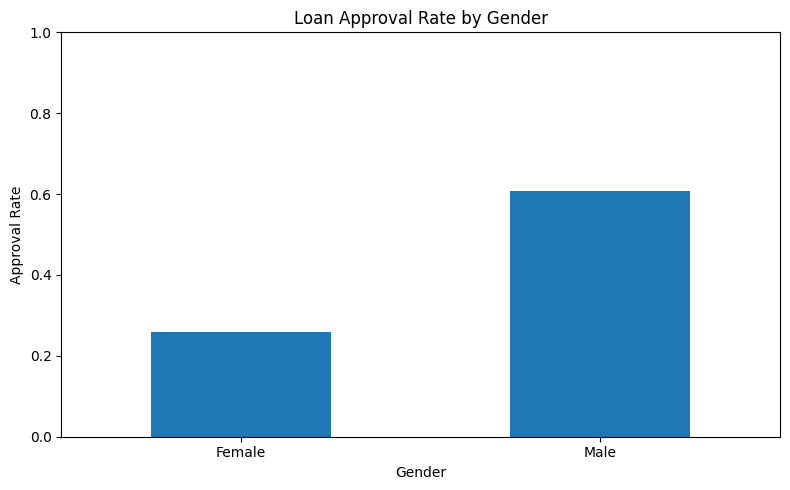

In [6]:
approval_by_gender = (
    df.groupby("gender")["loan_approved"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
approval_by_gender.plot(kind="bar")

plt.title("Loan Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


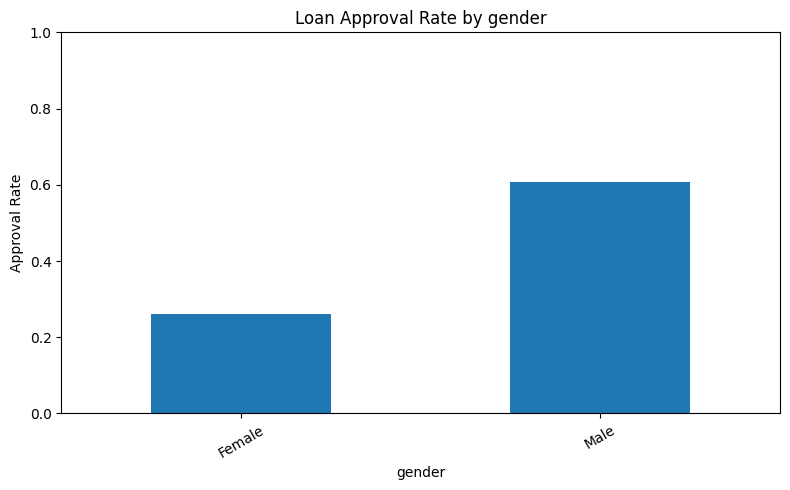

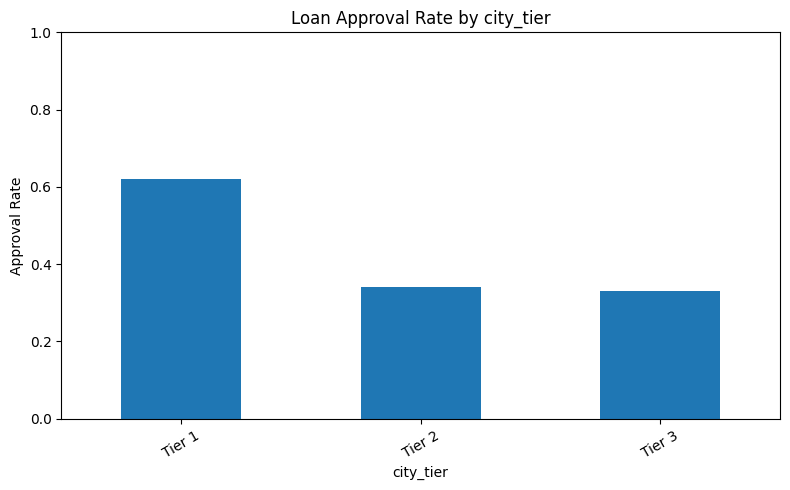

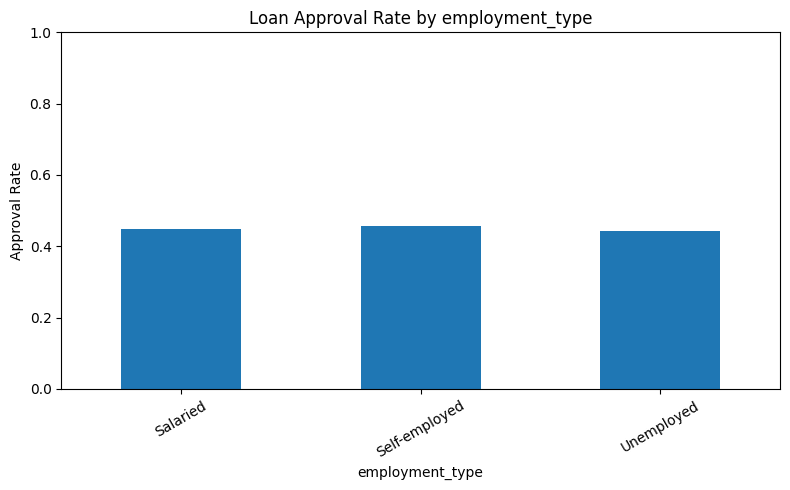

In [7]:
group_columns = [
    "gender",
    "city_tier",
    "employment_type"
]

for column in group_columns:
    approval_rates = df.groupby(column)["loan_approved"].mean()

    plt.figure(figsize=(8, 5))
    approval_rates.plot(kind="bar")

    plt.title(f"Loan Approval Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Approval Rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()